# Surveillance Camera Notebook: Algorithm Overview

This notebook implements a lightweight intruder-screening pipeline for uploaded surveillance videos.

## High-level algorithm
1. **Upload a video and read metadata**  
   Load the file, confirm it opens correctly, and inspect FPS, frame count, and duration.

2. **Temporally downsample the video**  
   Extract frames at a fixed sampling rate (5 FPS here) so the notebook keeps enough temporal detail without processing every original frame.

3. **Compute motion scores between consecutive sampled frames**  
   Convert each frame to grayscale, blur it slightly, and measure average absolute pixel change relative to the previous sampled frame.

4. **Detect anomalous motion with a rolling baseline**  
   For each time step, compare the current motion score to the recent local mean and standard deviation. If it is unusually high, mark that timestamp as suspicious.

5. **Group nearby suspicious timestamps into motion segments**  
   Merge flagged timestamps that are close in time into a single event window. This compresses many flagged frames into a few candidate events.

6. **Sample representative frames from each segment**  
   For each motion segment, take the start, middle, and end frames. These become the evidence frames sent to the vision model.

7. **Ask a vision model whether the segment contains a possible intruder**  
   The model receives the representative frames for a segment and returns a simple YES/NO answer.

8. **Aggregate segment-level answers into a final video-level decision**  
   If any segment is classified as containing a possible intruder, the notebook flags the video and displays the evidence frames.

## Why this structure is useful
- It avoids sending every frame to a vision model.
- It turns continuous motion into discrete event segments.
- It is cheap, modular, and easy to debug cell by cell.


In [ ]:
# Notebook purpose:
# - Install core dependencies used throughout the notebook
# - Upload a surveillance-style video from the local machine
# - Verify that OpenCV can open the file correctly
# - Read basic video metadata that later cells rely on
#
# Inputs:
# - A user-uploaded video file
#
# Outputs:
# - video_path: uploaded file name/path in the Colab runtime
# - fps: original video frame rate
# - frame_count: total number of frames in the original video
# - duration: total video length in seconds
#
# Why this cell exists:
# Every later stage depends on a valid video handle and correct metadata.
# This is the notebook's initialization step.

# =========================
# CELL 1: SETUP + UPLOAD
# =========================

# Install required packages
!pip -q install opencv-python-headless numpy

# Imports
import cv2
import numpy as np
from google.colab import files

# Upload video
uploaded = files.upload()

# Get video path
video_path = list(uploaded.keys())[0]
print("Uploaded video:", video_path)

# Load video
cap = cv2.VideoCapture(video_path)

if not cap.isOpened():
    raise ValueError("Error: Could not open video.")

# Extract metadata
fps = cap.get(cv2.CAP_PROP_FPS)
frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
duration = frame_count / fps if fps > 0 else 0

print(f"FPS: {fps}")
print(f"Total Frames: {frame_count}")
print(f"Duration (seconds): {duration:.2f}")

cap.release()

Saving ScreenRecording_04-08-2026 19-22-51_1.mov to ScreenRecording_04-08-2026 19-22-51_1 (1).mov
Uploaded video: ScreenRecording_04-08-2026 19-22-51_1 (1).mov
FPS: 43.4120945134161
Total Frames: 542
Duration (seconds): 12.48


In [ ]:
# Notebook purpose:
# - Downsample the uploaded video to a fixed temporal resolution
# - Extract one frame every 0.2 seconds (5 FPS)
# - Build a compact frame sequence for later motion analysis
#
# Inputs:
# - video_path from Cell 1
#
# Outputs:
# - frames: list of sampled frames
# - timestamps: list of timestamps aligned with each sampled frame
#
# Why this cell exists:
# Working on every original frame is unnecessary for a prototype.
# A fixed sampling rate keeps enough motion detail while making the
# notebook faster and easier to debug.

# =========================
# CELL 2: 5 FPS EXTRACTION
# =========================

cap = cv2.VideoCapture(video_path)

fps = cap.get(cv2.CAP_PROP_FPS)
frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
duration = frame_count / fps

sampling_rate = 5  # frames per second
step = 1 / sampling_rate

frames = []
timestamps = []

t = 0.0
while t <= duration:
    cap.set(cv2.CAP_PROP_POS_MSEC, t * 1000)
    ret, frame = cap.read()

    if not ret:
        print(f"Warning: Could not read frame at {t:.2f}s")
        t += step
        continue

    frames.append(frame)
    timestamps.append(round(t, 2))

    t += step

cap.release()

print(f"Extracted {len(frames)} frames ({sampling_rate} FPS)")
print("First 10 timestamps:", timestamps[:10])

Extracted 63 frames (5 FPS)
First 10 timestamps: [0.0, 0.2, 0.4, 0.6, 0.8, 1.0, 1.2, 1.4, 1.6, 1.8]


In [ ]:
# Notebook purpose:
# - Convert sampled frames into a 1D motion time series
# - Measure how much each sampled frame changes relative to the previous one
#
# Inputs:
# - frames from Cell 2
#
# Outputs:
# - motion_scores: average absolute pixel-difference score for each pair
#   of consecutive sampled frames
#
# Method summary:
# - Convert frames to grayscale
# - Apply a small Gaussian blur to reduce noise
# - Use absolute difference between consecutive frames
# - Take the mean of the difference image as the motion score
#
# Why this cell exists:
# This is the notebook's cheap anomaly signal. Instead of reasoning over
# all frames semantically, we first identify moments with unusually large
# visual change.

# =========================
# CELL 3: MOTION SCORING
# =========================

motion_scores = []

def preprocess(frame):
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)
    return blurred

for i in range(1, len(frames)):
    prev = preprocess(frames[i - 1])
    curr = preprocess(frames[i])

    diff = cv2.absdiff(curr, prev)
    score = np.mean(diff)

    motion_scores.append(score)

print(f"Computed {len(motion_scores)} motion scores")

# Quick stats
print(f"Min motion: {min(motion_scores):.4f}")
print(f"Max motion: {max(motion_scores):.4f}")
print(f"Mean motion: {np.mean(motion_scores):.4f}")

# Print first few scores
print("First 30 motion scores:", motion_scores[:30])

Computed 62 motion scores
Min motion: 0.0244
Max motion: 12.5557
Mean motion: 2.7931
First 30 motion scores: [np.float64(1.0446722732790013), np.float64(0.3886649133961428), np.float64(0.2857975454212666), np.float64(0.27595707377222894), np.float64(0.024394062000269733), np.float64(0.1106679768028823), np.float64(0.2128248848814134), np.float64(0.9168954588366761), np.float64(0.6287449665722598), np.float64(0.1402977669884207), np.float64(0.4705532435504691), np.float64(0.32423222164422094), np.float64(0.4219963200585708), np.float64(0.18474847311330753), np.float64(1.204441458104541), np.float64(1.2451471976571682), np.float64(0.8767701288942835), np.float64(0.8470656802111631), np.float64(2.0299452825462883), np.float64(1.5800844845191993), np.float64(0.7038369651079899), np.float64(1.2241272180798797), np.float64(2.545666917133884), np.float64(3.3285094310540817), np.float64(5.253504132709092), np.float64(4.550194593761439), np.float64(5.913475617979693), np.float64(2.4653704988150

In [ ]:
# Notebook purpose:
# - Detect locally unusual motion using a rolling time-series baseline
# - Flag timestamps where motion is much larger than recent history
#
# Inputs:
# - motion_scores from Cell 3
# - timestamps from Cell 2
#
# Outputs:
# - rolling_flags: boolean anomaly decisions over time
# - flagged_indices: positions in the sampled-frame list that were flagged
# - flagged_timestamps: timestamps of suspicious motion
#
# Method summary:
# - Look back over a rolling window of recent motion scores
# - Compute the local mean and local standard deviation
# - Mark the current point as suspicious if it exceeds
#   mean_local + k * std_local
#
# Why this cell exists:
# A global threshold can be brittle. A rolling threshold adapts to local
# conditions and is better suited to noisy real-world video.

# =========================
# CELL 4: ROLLING ANOMALY DETECTION
# =========================

window_size = 5   # ~1 second (since 5 FPS)
k = 2.0           # sensitivity

rolling_flags = []
flagged_indices = []
flagged_timestamps = []

for i in range(len(motion_scores)):
    if i < window_size:
        rolling_flags.append(False)
        continue

    window = motion_scores[i - window_size:i]

    mean_local = np.mean(window)
    std_local = np.std(window)

    threshold_local = mean_local + k * std_local

    if motion_scores[i] > threshold_local:
        rolling_flags.append(True)
        flagged_indices.append(i + 1)
        flagged_timestamps.append(timestamps[i + 1])
    else:
        rolling_flags.append(False)

print(f"Flagged {len(flagged_indices)} frames (rolling method)")
print("Flagged timestamps:", flagged_timestamps)

Flagged 10 frames (rolling method)
Flagged timestamps: [1.6, 3.0, 3.2, 3.8, 4.6, 4.8, 5.0, 7.2, 8.0, 9.4]


In [ ]:
# Notebook purpose:
# - Merge nearby suspicious timestamps into event segments
#
# Inputs:
# - flagged_timestamps from Cell 4
#
# Outputs:
# - segments: list of (start_time, end_time) motion windows
#
# Method summary:
# - If two flagged timestamps are close enough in time, treat them as
#   belonging to the same motion event
# - If the gap is too large, start a new segment
#
# Why this cell exists:
# Motion during one intrusion event often triggers many adjacent flags.
# Segmenting compresses those flags into a small number of candidate events.

# =========================
# CELL 5: SEGMENT FORMATION
# =========================

gap_tolerance = 1.0  # seconds (IMPORTANT)

segments = []

if len(flagged_timestamps) > 0:
    start = flagged_timestamps[0]
    prev = flagged_timestamps[0]

    for t in flagged_timestamps[1:]:
        if t - prev <= gap_tolerance:
            # still same segment
            prev = t
        else:
            # new segment
            segments.append((round(start, 2), round(prev, 2)))
            start = t
            prev = t

    segments.append((round(start, 2), round(prev, 2)))

print("Raw segments:", segments)

Raw segments: [(1.6, 1.6), (3.0, 5.0), (7.2, 8.0), (9.4, 9.4)]


In [ ]:
# Notebook purpose:
# - Choose representative evidence frames for each detected segment
#
# Inputs:
# - segments from Cell 5
# - frames and timestamps from Cell 2
#
# Outputs:
# - sampled_frames: three representative frames per segment
# - sampled_info: the timestamps of those representative frames
#
# Method summary:
# - For each segment, sample the start, midpoint, and end
# - Map each requested time to the nearest extracted frame
#
# Why this cell exists:
# Sending every flagged frame to a vision model is redundant and expensive.
# This cell compresses each motion segment into a small evidence set.

# =========================
# CELL 7: FRAME SAMPLING
# =========================

sampled_frames = []
sampled_info = []  # for debugging (timestamps)

for (start, end) in segments:
    # Choose 3 representative timestamps
    mid = (start + end) / 2

    sample_times = [start, mid, end]

    segment_frames = []
    segment_times = []

    for t in sample_times:
        # Find closest timestamp index
        idx = min(range(len(timestamps)), key=lambda i: abs(timestamps[i] - t))

        segment_frames.append(frames[idx])
        segment_times.append(timestamps[idx])

    sampled_frames.append(segment_frames)
    sampled_info.append(segment_times)

print("Sampled timestamps per segment:", sampled_info)

Sampled timestamps per segment: [[1.6, 1.6, 1.6], [3.0, 4.0, 5.0], [7.2, 7.6, 8.0], [9.4, 9.4, 9.4]]


In [ ]:
# Notebook purpose:
# - Provide the OpenAI API key used by the vision-check stage
#
# Inputs:
# - A valid OpenAI API key string
#
# Outputs:
# - OPENAI_API_KEY stored in the runtime environment
#
# Why this cell exists:
# The next cell calls the OpenAI API. It reads credentials from the runtime
# environment rather than passing the key into each request manually.

import os
os.environ["OPENAI_API_KEY"] = "Put your open AI Key here"

In [ ]:
# Notebook purpose:
# - Ask a vision model whether each motion segment contains someone who
#   might possibly be an intruder
#
# Inputs:
# - sampled_frames from Cell 6
#
# Outputs:
# - segment_results: YES/NO response for each segment
#
# Method summary:
# - Encode each representative frame as base64
# - Send all representative frames for one segment in a single request
# - Ask for a strict YES/NO answer only
#
# Why this cell exists:
# Earlier cells only identify motion. This cell adds semantic judgment:
# whether the motion segment visually contains a possible intruder.

# =========================
# CELL 8: GPT VISION CHECK
# =========================

import base64
from openai import OpenAI

client = OpenAI()

def encode_image(frame):
    _, buffer = cv2.imencode('.jpg', frame)
    return base64.b64encode(buffer).decode('utf-8')

segment_results = []

for segment_idx, segment in enumerate(sampled_frames):

    images_base64 = [encode_image(img) for img in segment]

    content = [
        {
            "type": "text",
            "text": (
                "Do you see anyone that might possibly be an intruder in any of these images? Even a small sign should be considered a YES\n\n"
                "Rules:\n"
                "- Answer ONLY YES or NO\n"
            )
        }
    ]

    # Add images
    for img_b64 in images_base64:
        content.append({
            "type": "image_url",
            "image_url": {"url": f"data:image/jpeg;base64,{img_b64}"}
        })

    response = client.chat.completions.create(
        model="gpt-4o-mini",
        messages=[{"role": "user", "content": content}],
        max_tokens=100
    )

    answer = response.choices[0].message.content.strip().upper()
    segment_results.append(answer)

    print(f"Segment {segment_idx} → GPT says: {answer}")

print("All segment results:", segment_results)

Segment 0 → GPT says: NO
Segment 1 → GPT says: NO
Segment 2 → GPT says: YES
Segment 3 → GPT says: YES
All segment results: ['NO', 'NO', 'YES', 'YES']



FINAL RESULT
Segment Results: ['NO', 'NO', 'YES', 'YES']
Segments: [(1.6, 1.6), (3.0, 5.0), (7.2, 8.0), (9.4, 9.4)]

🚨 INTRUDER DETECTED

Intruder segments: [(7.2, 8.0), (9.4, 9.4)]

Displaying evidence frames:

Segment (7.2, 8.0):


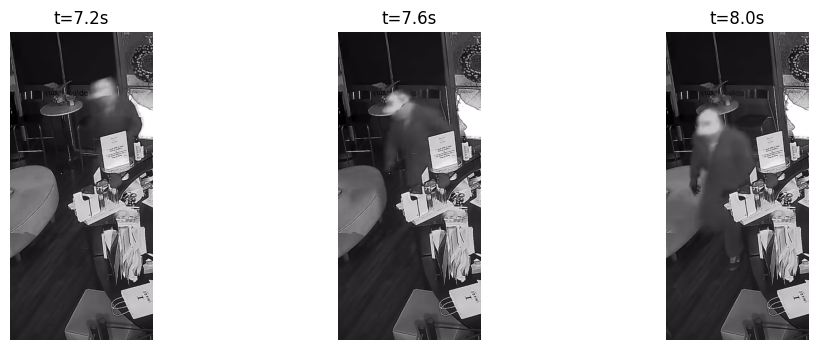

Segment (9.4, 9.4):


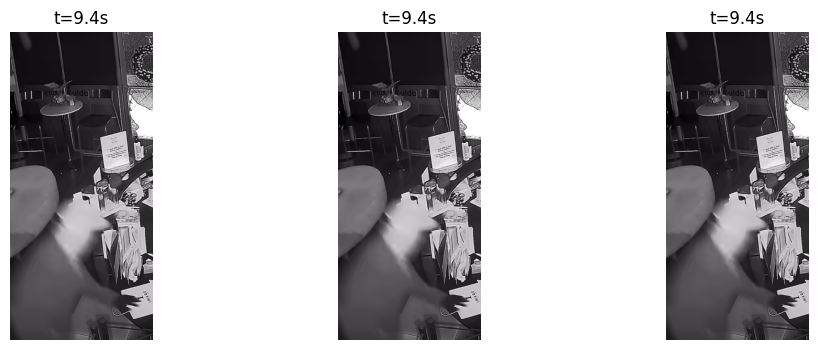

In [ ]:
# Notebook purpose:
# - Convert segment-level model answers into a final video-level decision
# - Display visual evidence for any segment classified as positive
#
# Inputs:
# - segment_results from Cell 8
# - segments from Cell 5
# - sampled_frames and sampled_info from Cell 6
#
# Outputs:
# - intruder_detected: final boolean decision for the full video
# - intruder_segments: the segments classified as containing an intruder
# - Visual evidence plots for positive segments
#
# Method summary:
# - Normalize raw model outputs into YES/NO
# - Mark the full video as positive if any segment is positive
# - Show the representative frames for each positive segment
#
# Why this cell exists:
# This is the notebook's decision and explainability layer. It both
# reports the final result and shows the evidence used to support it.

# =========================
# CELL 9: FINAL DECISION + VISUALIZATION
# =========================

import matplotlib.pyplot as plt

# Normalize responses
normalized_results = []

for r in segment_results:
    if "YES" in r:
        normalized_results.append("YES")
    else:
        normalized_results.append("NO")

# Final decision
intruder_detected = any(r == "YES" for r in normalized_results)

print("\n=========================")
print("FINAL RESULT")
print("=========================")

print("Segment Results:", normalized_results)
print("Segments:", segments)

if intruder_detected:
    print("\n🚨 INTRUDER DETECTED")
else:
    print("\n✅ No intruder detected")

# Identify intruder segments
intruder_segments = [
    segments[i]
    for i in range(len(normalized_results))
    if normalized_results[i] == "YES"
]

print("\nIntruder segments:", intruder_segments)


# =========================
# SHOW VISUAL EVIDENCE
# =========================

if intruder_detected:
    print("\nDisplaying evidence frames:\n")

    for i, result in enumerate(normalized_results):
        if result == "YES":
            segment = segments[i]
            frames_in_segment = sampled_frames[i]

            print(f"Segment {segment}:")

            plt.figure(figsize=(12, 4))

            for j, frame in enumerate(frames_in_segment):
                plt.subplot(1, len(frames_in_segment), j + 1)
                plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
                plt.title(f"t={sampled_info[i][j]}s")
                plt.axis('off')

            plt.show()